# Hospital Readmission Prediction Model
### Predicting 30-day readmissions using machine learning on 70,416 diabetic patient records

---

| Detail | Info |
|---|---|
| Dataset | Diabetes 130-US Hospitals (1999–2008) |
| Target | Readmitted within 30 days (binary) |
| Best Model | Random Forest |
| ROC-AUC | 0.682 |
| Author | Cephas Adams Kumah |
| Date | March 2025 |


## 1. Data Loading & Setup

In [4]:
#imports and load clean data
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, classification_report,
                             ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

df = pd.read_csv("../data/diabetic_data_features.csv")
print(f"Loaded: {df.shape}")

Loaded: (70416, 46)


In [3]:
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Global chart styling
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'grid.linestyle':   '--',
    'font.family':      'sans-serif',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
})

print("Plot styling applied.")


Plot styling applied.


## 2. Feature Engineering

In [5]:
#Split features and target
X = df.drop(columns=["readmitted_30"])
y = df["readmitted_30"]

print(f"Features: {X.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True).mul(100).round(1)}")

Features: (70416, 45)
Target distribution:
readmitted_30
0    93.1
1     6.9
Name: proportion, dtype: float64


## 3. Model Training

In [6]:
# --Train/test split with stratification to preserve class balance 
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                   test_size=0.2,
                                                   random_state=42,
                                                   stratify=y    # ensures same 7/93 ratio in both train and test 
                                                   )

print(f"Training rows: {X_train.shape[0]}")
print(f"Test rows: {X_train.shape[0]}")
print(f"Positive rate in train: {y_train.mean()*100:.1f}%")
print(f"Positive rate in test: {y_test.mean()*100:.1f}%")

Training rows: 56332
Test rows: 56332
Positive rate in train: 6.9%
Positive rate in test: 6.9%


In [7]:
#Training both models
#Model 1: Logistic Regression (with scaling pipeline)
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight= "balanced", 
                                 max_iter=1000, random_state=42))
])

#Model 2: Random Forest (no scaling needed)
rf_model = RandomForestClassifier(
    class_weight="balanced",
    n_estimators=200,
    max_depth=10,                  #prevents trees from just predicting the majority class
    min_samples_leaf=5,            #forces trees to consider minority class
    max_features="sqrt",
    random_state=42,
    n_jobs=-1 #uses all CPU cores to speed up training
)

lr_pipeline.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

print("Both models trained.")

Both models trained.


## 4. Evaluation & Results

In [8]:
#Evaluating both models

from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

models = {
    "Logistic Regression": lr_pipeline,
    "Random Forest": rf_model
        }

results = {}


for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_prob)

    
    # Find threshold that maximises F1 score for minority class
    precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    y_pred = (y_prob >= best_threshold).astype(int) 
    results[name] = {
        "roc_auc" : roc_auc, 
        "y_pred" :  y_pred, 
        "y_prob" :  y_prob,
        "best_threshold": best_threshold
    }
    print(f"\n{"=" *40}")
    print(f"{name}")
    print(f"ROC_AUC: {roc_auc:.3f}")
    print(f"Best F1(minority): {best_f1:.3f}")
    print(classification_report(y_test, y_pred, 
        target_names=["Not readmitted", "readmitted"]))


Logistic Regression
ROC_AUC: 0.675
Best F1(minority): 0.204
                precision    recall  f1-score   support

Not readmitted       0.95      0.82      0.88     13117
    readmitted       0.14      0.39      0.20       967

      accuracy                           0.79     14084
     macro avg       0.54      0.61      0.54     14084
  weighted avg       0.89      0.79      0.83     14084


Random Forest
ROC_AUC: 0.682
Best F1(minority): 0.212
                precision    recall  f1-score   support

Not readmitted       0.95      0.83      0.89     13117
    readmitted       0.15      0.39      0.21       967

      accuracy                           0.80     14084
     macro avg       0.55      0.61      0.55     14084
  weighted avg       0.89      0.80      0.84     14084



## Key Findings

- **Random Forest** outperforms Logistic Regression (ROC-AUC: 0.682 vs 0.675)
- Optimal decision threshold: **0.13** (lower than default 0.5 due to 7% class imbalance)
- Model correctly flags **39% of true readmissions** for clinical intervention
- **5,927 patients** classified as high risk out of 70,416

### What would improve this model
- Engineer ICD-9 diagnosis codes into 9 clinical categories
- Add Charlson Comorbidity Index score
- Try XGBoost or LightGBM
- Collect more recent data (current dataset is 1999–2008)

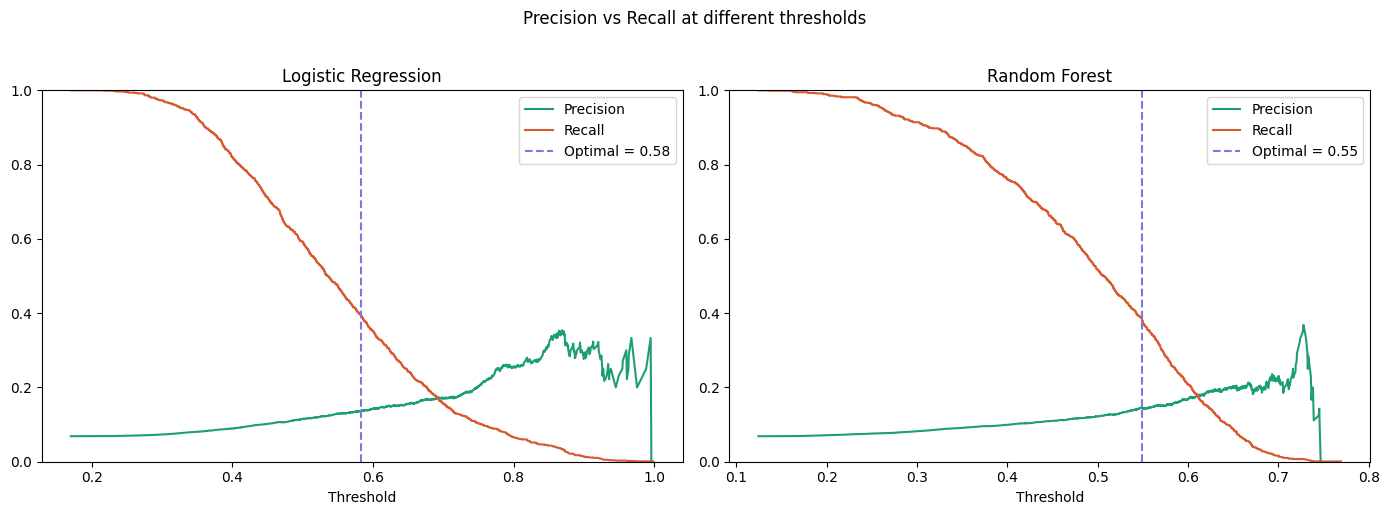

In [9]:
#PLOT PRECISION VS RECALL TRADEOFF
fig, axes = plt.subplots(1, 2, figsize=(14,5))

for ax, (name,res) in zip(axes, results.items()):
    precisions, recalls, thresholds = precision_recall_curve(y_test, res["y_prob"])

    ax.plot(thresholds, precisions[:-1], label="Precision", color="#1D9E75")
    ax.plot(thresholds, recalls[:-1], label="Recall",     color="#D85A30")
    ax.axvline(res["best_threshold"], color= "#7F77DD",
              linestyle="--", label=f"Optimal = {res["best_threshold"]:.2f}")
    ax.set_xlabel("Threshold")
    ax.set_title(f"{name}")
    ax.legend()
    ax.set_ylim(0, 1)

plt.suptitle("Precision vs Recall at different thresholds", y=1.02)
plt.tight_layout()
plt.savefig("../visuals/visuals_precision_recall_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

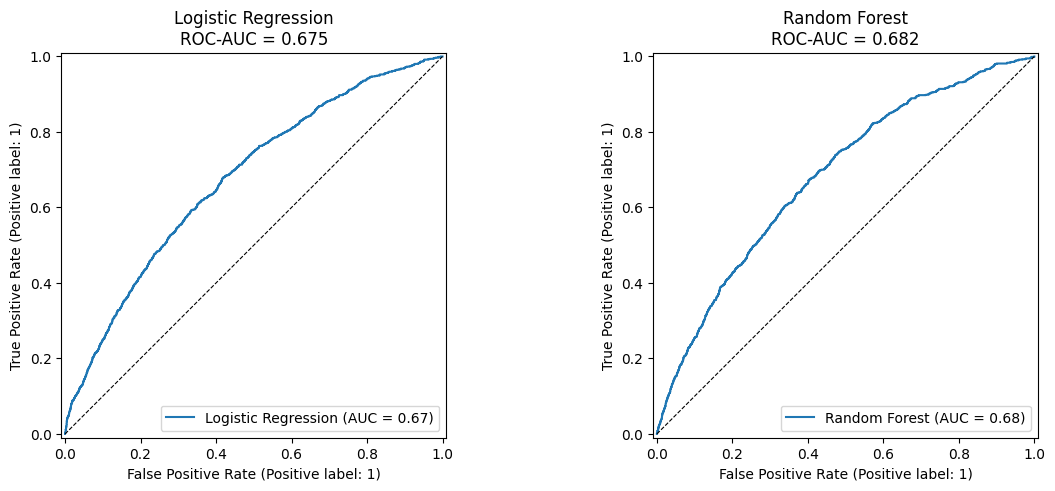

ROCcurves saved.


In [10]:
#PLOT ROC CURVES SIDE BY SIDE
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, res) in zip(axes, results.items()):
    RocCurveDisplay.from_predictions(
        y_test, res["y_prob"],
        name=name, ax=ax
    )
    ax.set_title(F"{name}\nROC-AUC = {res["roc_auc"]:.3f}")
    ax.plot([0,1], [0,1], "k--", linewidth=0.8)

plt.tight_layout
plt.savefig("../visuals/visuals_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("ROCcurves saved.")

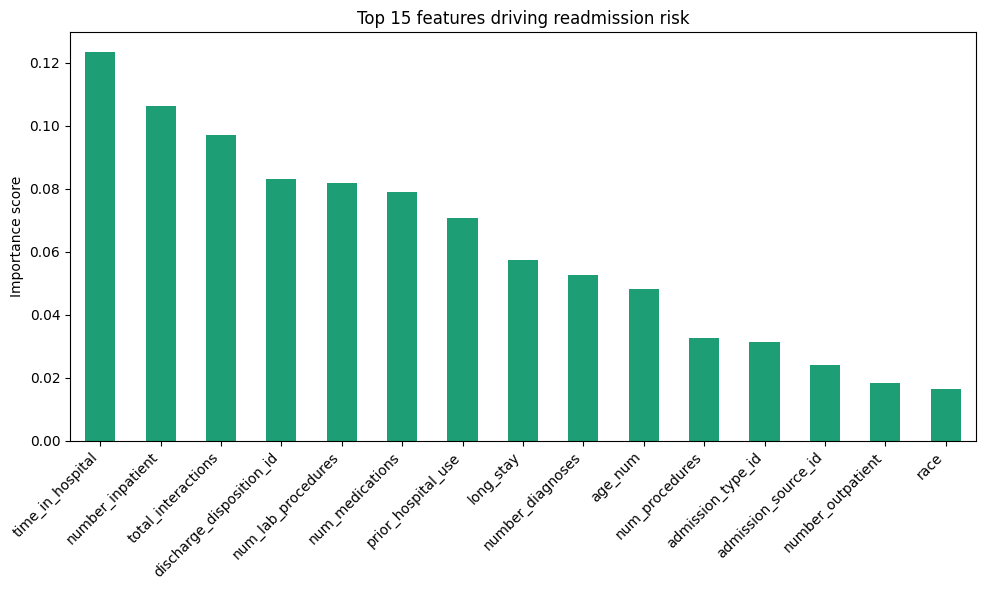

Feature importances saved.


In [16]:
#FEATURE IMPORTANCE (FOR RANDOM FOREST)

importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
importances.plot(kind="bar", color="#1D9E75")
plt.title("Top 15 features driving readmission risk")
plt.ylabel("Importance score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../visuals/visuals_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


#save for Power BI
importances.reset_index().rename(
    columns={"index": "feature", 0: "importance"}
).to_csv("../data/feature_importances.csv", index=False)

print("Feature importances saved.")

## 5. Export for Power BI

In [13]:
#Export predictions for Power BI 
final_threshold = results["Random Forest"]["best_threshold"]
full_probs = rf_model.predict_proba(X)[:,1]
full_preds = (full_probs >= final_threshold).astype(int)
              


output = df.copy()
output["readmission_probability"] = full_probs
output["predicted_readmitted"] = full_preds
output["risk_category"] = pd.cut(
    output["readmission_probability"],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low', "Medium", "High"]
)

output.to_csv("../data/predictions.csv", index=False)
print(f"Predictions saved: {output.shape}")
print(f"\nRisk category breakdown:")
print(output["risk_category"].value_counts())

Predictions saved: (70416, 49)

Risk category breakdown:
risk_category
Medium    47674
Low       16815
High       5927
Name: count, dtype: int64


In [14]:
age_label_map = {
    1:'0-10',   2:'10-20',  3:'20-30',  4:'30-40',  5:'40-50',
    6:'50-60',  7:'60-70',  8:'70-80',  9:'80-90',  10:'90-100'
}

# Add age_group to the output dataframe (not df)
output['age_group'] = output['age_num'].map(age_label_map)

# Confirm the key columns are still there
print("Columns present:")
print([c for c in output.columns if c in [
    'readmission_probability', 'risk_category',
    'predicted_readmitted', 'readmitted_30', 'age_group'
]])

# Save the correct file
output.to_csv('../data/predictions.csv', index=False)
print(f"\nSaved correctly: {output.shape}")
print(output['age_group'].value_counts().sort_index())

Columns present:
['readmitted_30', 'readmission_probability', 'predicted_readmitted', 'risk_category', 'age_group']

Saved correctly: (70416, 50)
age_group
0-10      2029
10-20      353
20-30     1029
30-40     2562
40-50     6646
50-60    12266
60-70    15795
70-80    18069
80-90    11667
Name: count, dtype: int64


In [15]:
print(output[output['risk_category']=='High']['age_group'].value_counts())

age_group
70-80    2024
80-90    1429
60-70    1249
50-60     668
40-50     339
30-40     118
0-10       56
20-30      36
10-20       8
Name: count, dtype: int64
